In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB3
from keras.applications import VGG16

# ignore the warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# loading the dataset
def loading_the_data(data_dir):
    # Generate data paths with labels
    filepaths = []
    labels = []

    # Get folder names
    folds = os.listdir(data_dir)

    for fold in folds:
        foldpath = os.path.join(data_dir, fold)
        filelist = os.listdir(foldpath)
        for file in filelist:
            fpath = os.path.join(foldpath, file)
            
            filepaths.append(fpath)
            labels.append(fold)

    # Concatenate data paths with labels into one DataFrame
    Fseries = pd.Series(filepaths, name='filepaths')
    Lseries = pd.Series(labels, name='labels')

    df = pd.concat([Fseries, Lseries], axis=1)
    
    return df

In [ ]:
# loading the data
data_dir = 'C:/Users/KIIT0001/Downloads/Mini Project/dataset/flowers'
df = loading_the_data(data_dir)

df

,filepaths,labels
0,C:/Users/KIIT0001/Downloads/Mini Project/datas...,daisy
1,C:/Users/KIIT0001/Downloads/Mini Project/datas...,daisy
2,C:/Users/KIIT0001/Downloads/Mini Project/datas...,daisy
3,C:/Users/KIIT0001/Downloads/Mini Project/datas...,daisy
4,C:/Users/KIIT0001/Downloads/Mini Project/datas...,daisy
...,...,...
4312,C:/Users/KIIT0001/Downloads/Mini Project/datas...,tulip
4313,C:/Users/KIIT0001/Downloads/Mini Project/datas...,tulip
4314,C:/Users/KIIT0001/Downloads/Mini Project/datas...,tulip
4315,C:/Users/KIIT0001/Downloads/Mini Project/datas...,tulip


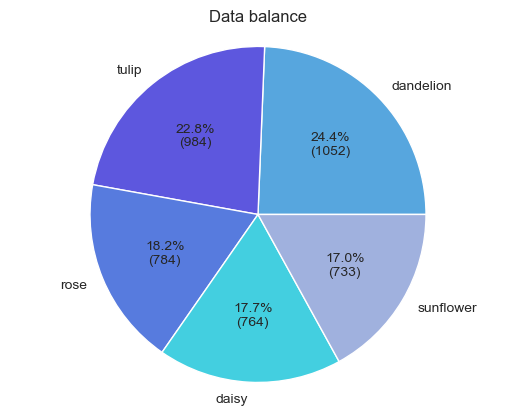

In [5]:
data_balance = df.labels.value_counts()


def custom_autopct(pct):
    total = sum(data_balance)
    val = int(round(pct*total/100.0))
    return "{:.1f}%\n({:d})".format(pct, val)


# pie chart for data balance
plt.pie(data_balance, labels = data_balance.index, autopct=custom_autopct, colors = ["#57A6DE","#5D57DE","#577BDE","#43CFE0","#A0B1DE"])
plt.title("Data balance")
plt.axis("equal")
plt.show()

In [6]:
train_df, ts_df = train_test_split(df, train_size = 0.8, shuffle = True, random_state = 42)

# test data --> 10% train data && 10% (test, val)
valid_df, test_df = train_test_split(ts_df, train_size = 0.5, shuffle = True, random_state = 42)

In [7]:
print(df.head())
print("Total rows:", len(df))

                                           filepaths labels
0  C:/Users/KIIT0001/Downloads/Mini Project/datas...  daisy
1  C:/Users/KIIT0001/Downloads/Mini Project/datas...  daisy
2  C:/Users/KIIT0001/Downloads/Mini Project/datas...  daisy
3  C:/Users/KIIT0001/Downloads/Mini Project/datas...  daisy
4  C:/Users/KIIT0001/Downloads/Mini Project/datas...  daisy
Total rows: 4317


In [8]:
batch_size = 16
img_size = (224, 224)

# Create generators for the data
tr_gen = ImageDataGenerator(rescale=1. / 255)
ts_gen = ImageDataGenerator(rescale=1. / 255)


# Convert the data
train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

valid_gen = ts_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= False, batch_size= batch_size)


Found 3453 validated image filenames belonging to 5 classes.
Found 432 validated image filenames belonging to 5 classes.
Found 432 validated image filenames belonging to 5 classes.


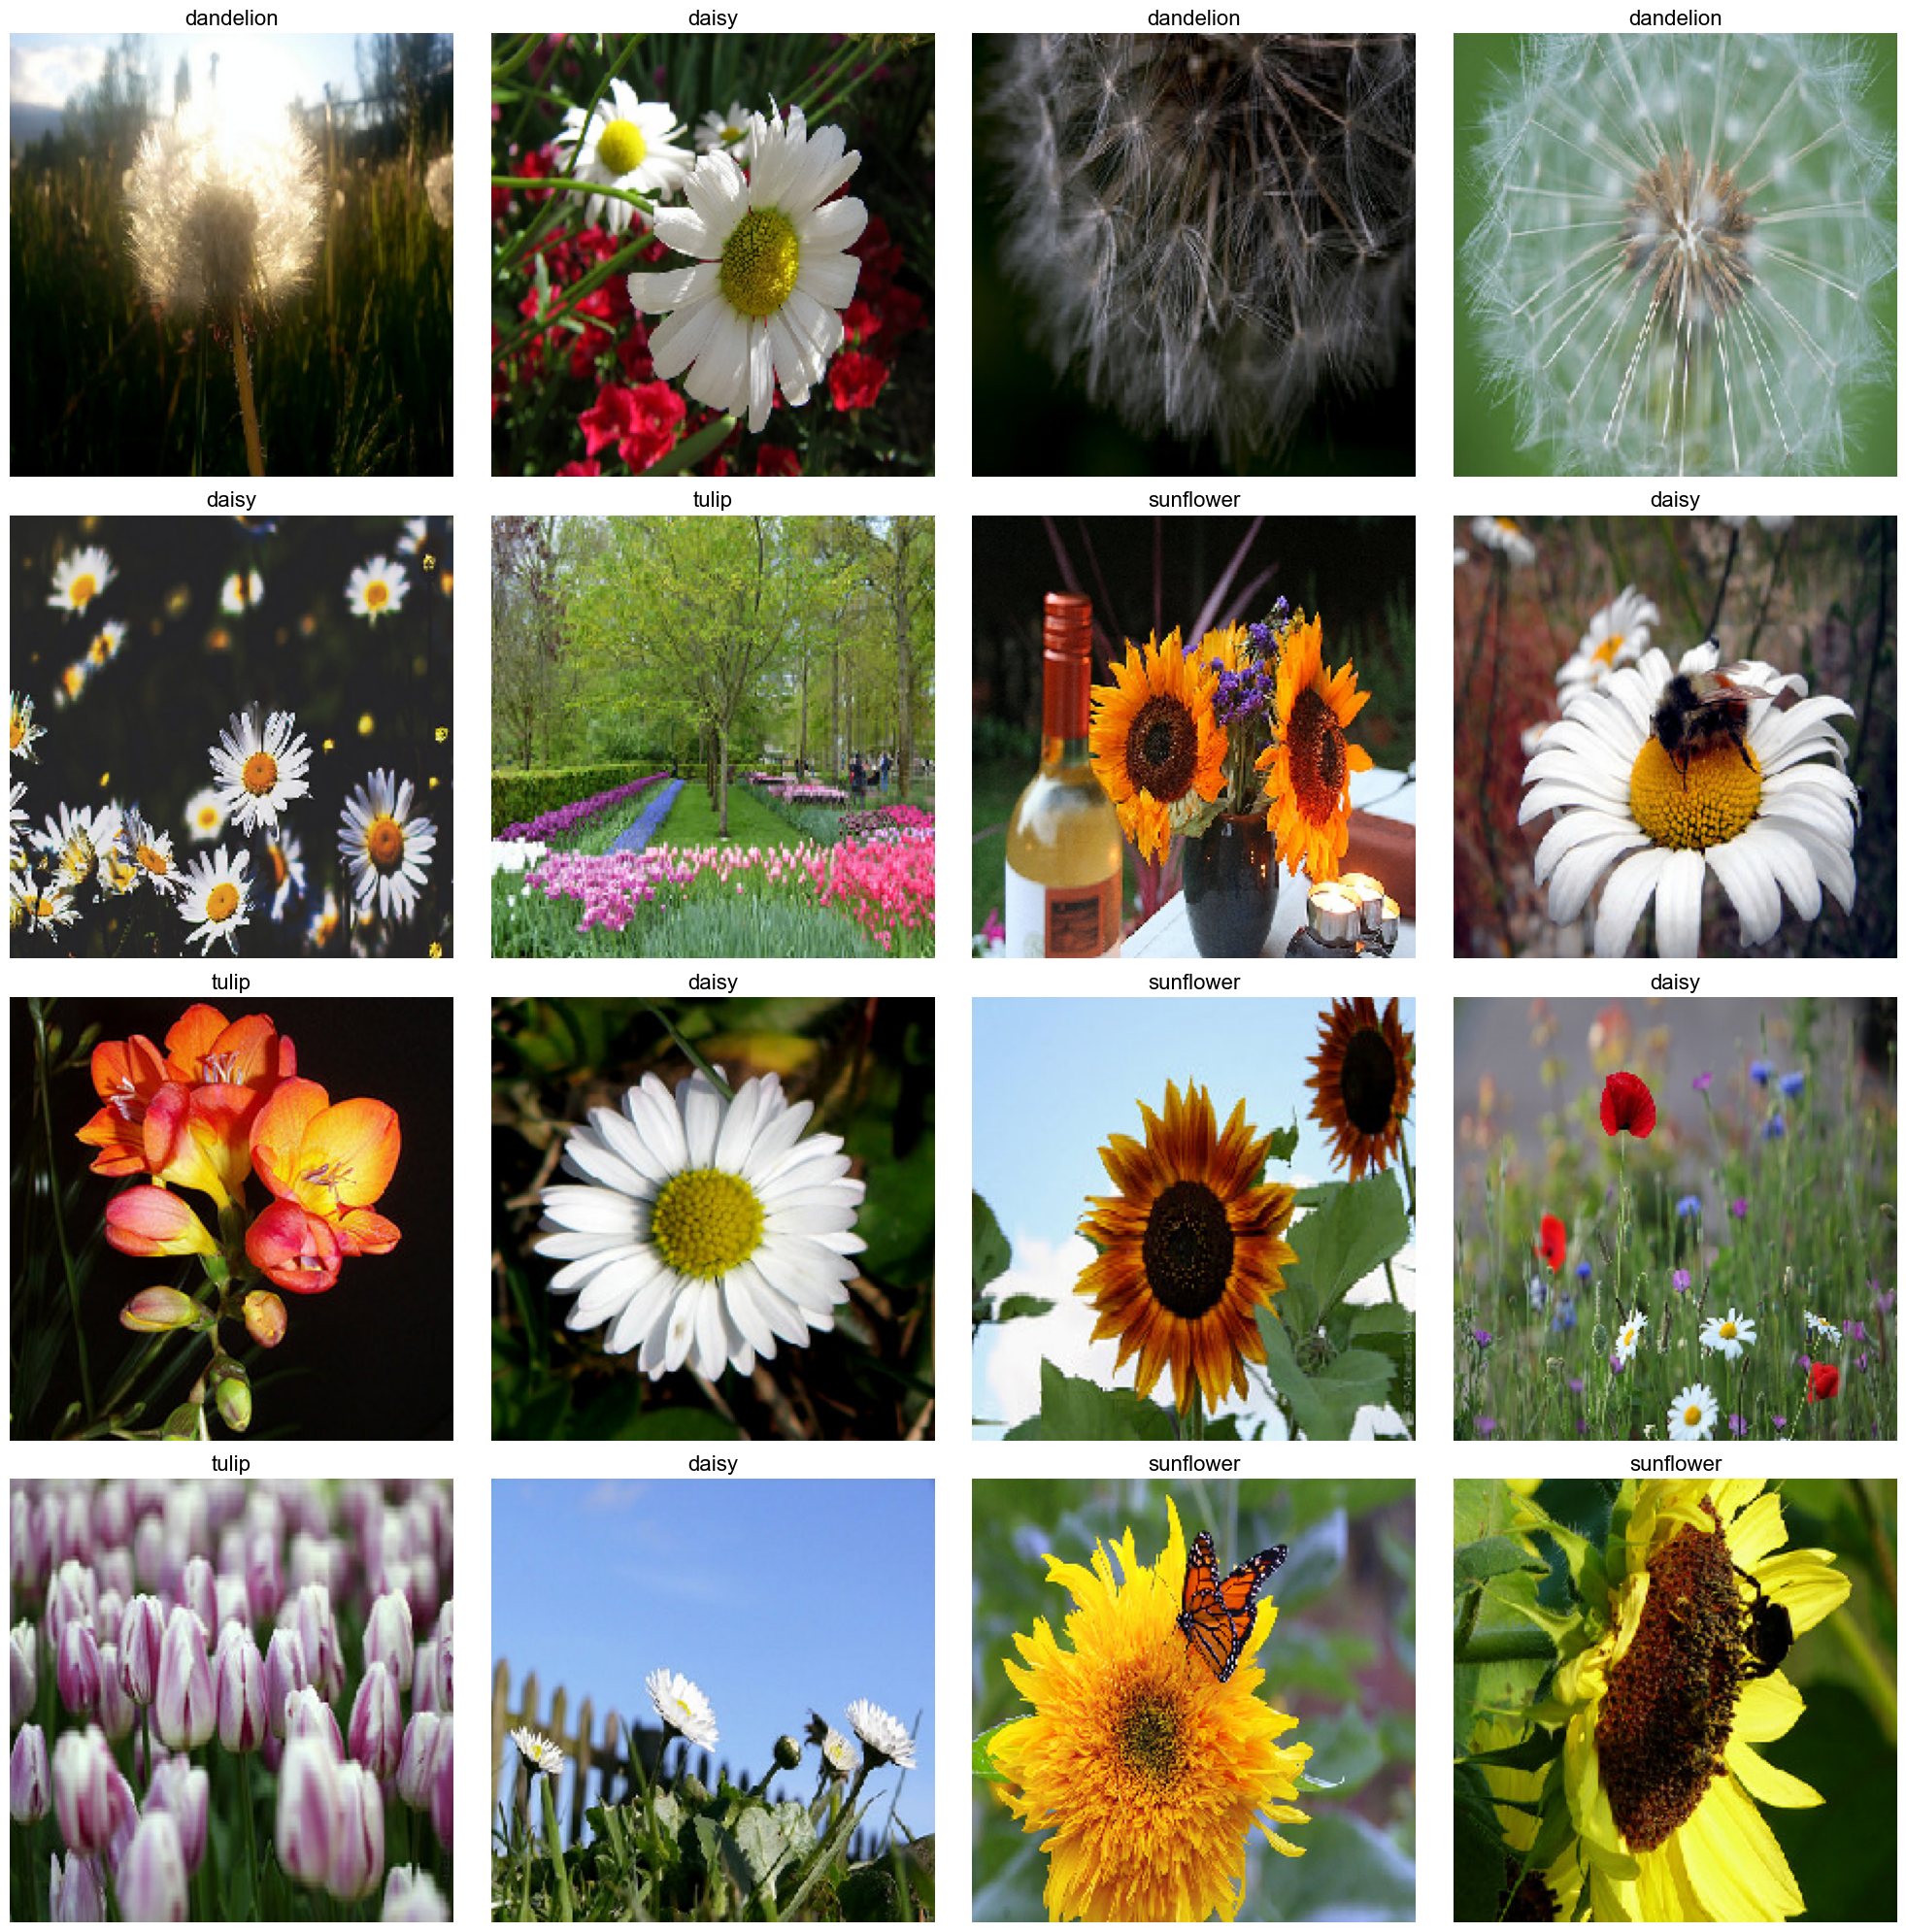

In [9]:
g_dict = train_gen.class_indices      # defines dictionary {'class': index}
classes = list(g_dict.keys())       # defines list of dictionary's kays (classes), classes names : string
images, labels = next(train_gen)      # get a batch size samples from the generator

# ploting the patch size samples
plt.figure(figsize= (20, 20))

for i in range(batch_size):
    plt.subplot(4, 4, i + 1)
    image = images[i]
    plt.imshow(image)
    index = np.argmax(labels[i])  # get image index
    class_name = classes[index]   # get class of image
    plt.title(class_name, color= 'black', fontsize= 16)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [10]:
# Displaying the model performance
def model_performance(history, Epochs):
    # Define needed variables
    tr_acc = history.history['accuracy']
    tr_loss = history.history['loss']
    val_acc = history.history['val_accuracy']
    val_loss = history.history['val_loss']
    
    Epochs = [i+1 for i in range(len(tr_acc))]
    
    # Plot training history
    plt.figure(figsize= (20, 8))
    plt.style.use('fivethirtyeight')
    
    plt.subplot(1, 2, 1)
    plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
    plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
    plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout
    plt.show()
    

# Evaluate the model
def model_evaluation(model):
    train_score = model.evaluate(train_gen, verbose= 1)
    valid_score = model.evaluate(valid_gen, verbose= 1)
    test_score = model.evaluate(test_gen, verbose= 1)
    
    print("Train Loss: ", train_score[0])
    print("Train Accuracy: ", train_score[1])
    print('-' * 20)
    print("Validation Loss: ", valid_score[0])
    print("Validation Accuracy: ", valid_score[1])
    print('-' * 20)
    print("Test Loss: ", test_score[0])
    print("Test Accuracy: ", test_score[1])
    

# Get Predictions
def get_pred(model, test_gen):
    
    preds = model.predict(test_gen)
    y_pred = np.argmax(preds, axis = 1)
    
    return y_pred


# Confusion Matrix
def plot_confusion_matrix(test_gen, y_pred):
    
    g_dict = test_gen.class_indices
    classes = list(g_dict.keys())
    
    # Display the confusion matrix
    cm = confusion_matrix(test_gen.classes, y_pred)

    plt.figure(figsize= (10, 10))
    plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation= 45)
    plt.yticks(tick_marks, classes)
    
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')
    
    
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    plt.show()
    
    
# Defining a convolutional NN block for a sequential CNN model
def conv_block(filters, act='relu'):
    
    block = Sequential()
    block.add(Conv2D(filters, 3, activation=act, padding='same'))
    block.add(Conv2D(filters, 3, activation=act, padding='same'))
    block.add(BatchNormalization())
    block.add(MaxPooling2D())
    
    return block


# Defining a dense NN block for a sequential CNN model
def dense_block(units, dropout_rate, act='relu'):
    
    block = Sequential()
    block.add(Dense(units, activation=act))
    block.add(BatchNormalization())
    block.add(Dropout(dropout_rate))
    
    return block

In [11]:
# create Model structure
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

class_counts = len(list(train_gen.class_indices.keys()))     # to define number of classes in dense layer

In [12]:
# Model architecture
cnn_model = Sequential()

# first conv block
cnn_model.add(Conv2D(filters=16, kernel_size=(3,3), padding="same", activation="relu", input_shape= img_shape))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D())

# second conv block
cnn_model.add(conv_block(32))

# third conv block
cnn_model.add(conv_block(64))

# fourth conv bolck
cnn_model.add(conv_block(128))

# fifth conv block
cnn_model.add(conv_block(256))

# sixth conv block
cnn_model.add(conv_block(512))

# flatten layer
cnn_model.add(Flatten())

# first dense block
cnn_model.add(dense_block(256, 0.5))

# second dense block
cnn_model.add(dense_block(128, 0.3))

# third dense block
cnn_model.add(dense_block(64, 0.2))

# fourth dense block
cnn_model.add(dense_block(32, 0.2))

# output layer
cnn_model.add(Dense(class_counts, activation = "softmax"))

In [13]:
cnn_model.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 56, 56, 32)     │        14,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 28, 28, 64)     │        55,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 14, 14, 128)    │       221,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 7, 7, 256)      │       886,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 3, 3, 512)      │     3,542,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 256)            │     1,180,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 128)            │        33,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_8 (Sequential)       │ (None, 64)             │         8,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_9 (Sequential)       │ (None, 32)             │         2,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,945,669 (22.68 MB)

 Trainable params: 5,942,693 (22.67 MB)

 Non-trainable params: 2,976 (11.62 KB)

In [16]:
# train the model
epochs = 20   # number of all epochs in training
9
history = cnn_model.fit(train_gen, epochs= epochs, verbose= 1, validation_data= valid_gen, shuffle= False)

Epoch 1/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 595s 3s/step - accuracy: 0.2418 - loss: 1.9170 - val_accuracy: 0.2616 - val_loss: 2.0529
Epoch 2/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - accuracy: 0.2893 - loss: 1.7128 - val_accuracy: 0.2662 - val_loss: 1.7554
Epoch 3/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 374s 2s/step - accuracy: 0.3455 - loss: 1.5674 - val_accuracy: 0.3819 - val_loss: 1.4329
Epoch 4/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 424s 2s/step - accuracy: 0.3863 - loss: 1.4603 - val_accuracy: 0.4745 - val_loss: 1.3264
Epoch 5/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 491s 2s/step - accuracy: 0.4445 - loss: 1.3574 - val_accuracy: 0.5324 - val_loss: 1.1803
Epoch 6/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 416s 2s/step - accuracy: 0.5033 - loss: 1.2289 - val_accuracy: 0.5486 - val_loss: 1.1736
Epoch 7/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 430s 2s/step - accuracy: 0.5259 - loss: 1.1706 - val_accuracy: 0.6065 - val_loss: 1.0408
Epoch 8/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 6054s 28s/step - accuracy: 0.5453 - loss: 1.1387 - val_ac

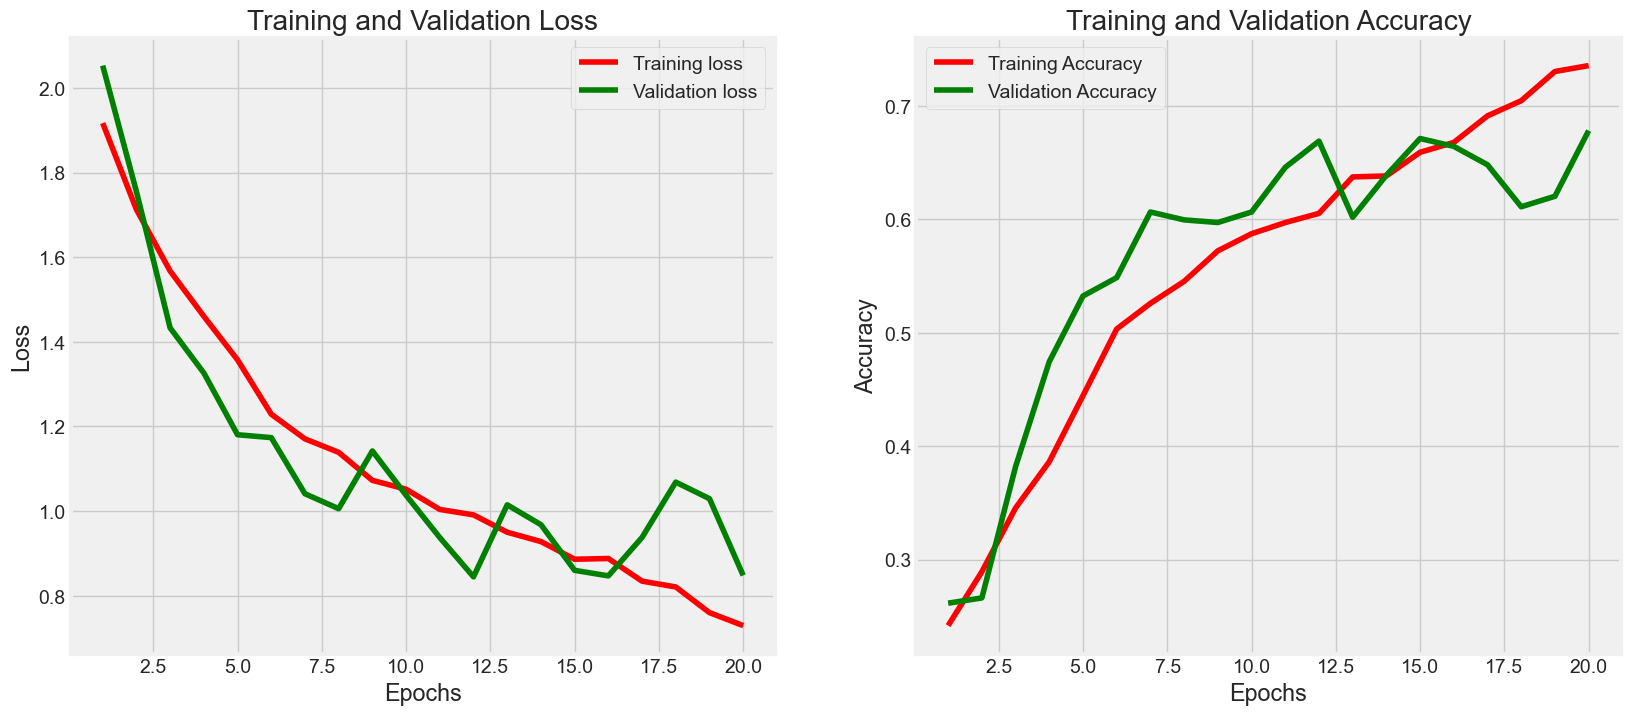

In [17]:
# Display model performance
model_performance(history, epochs)

In [18]:
# Model evaluation
model_evaluation(cnn_model)

216/216 ━━━━━━━━━━━━━━━━━━━━ 71s 327ms/step - accuracy: 0.7347 - loss: 0.7018
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 332ms/step - accuracy: 0.6782 - loss: 0.8477
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 710ms/step - accuracy: 0.6667 - loss: 0.9159
Train Loss:  0.7018436193466187
Train Accuracy:  0.7347234487533569
--------------------
Validation Loss:  0.8477423191070557
Validation Accuracy:  0.6782407164573669
--------------------
Test Loss:  0.9159001111984253
Test Accuracy:  0.6666666865348816


27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 351ms/step


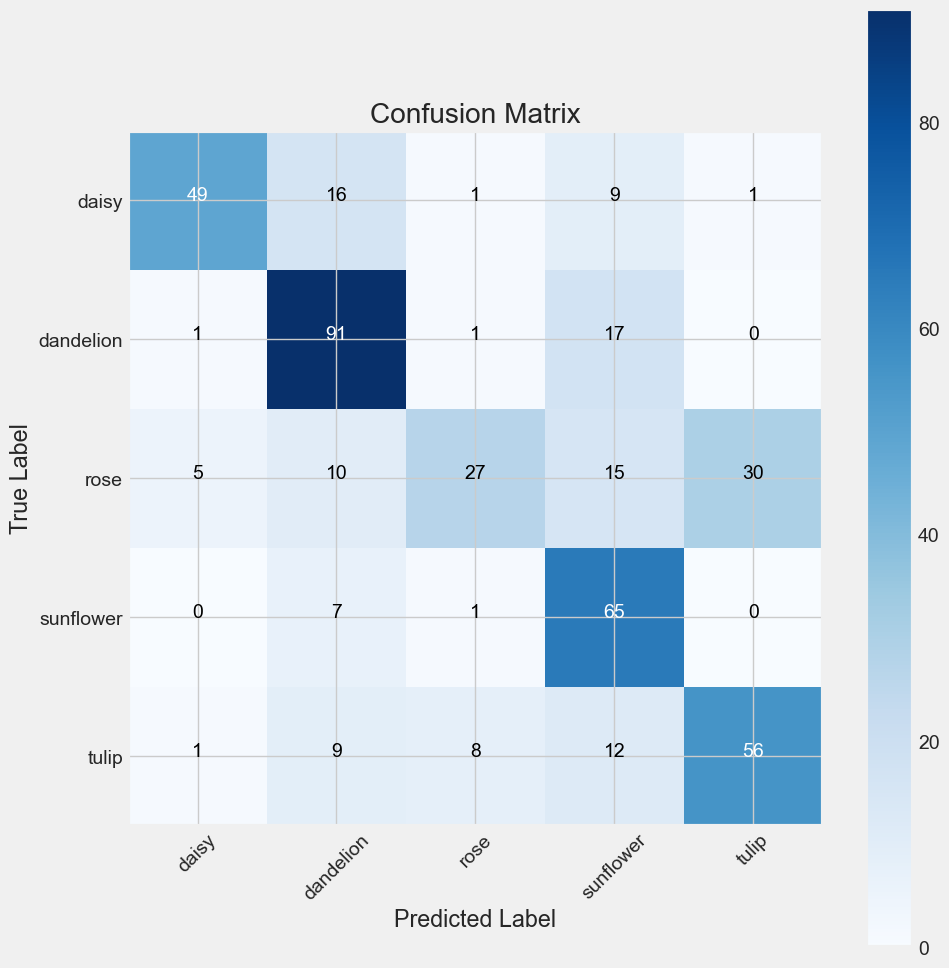

In [19]:
# get predictions
import itertools

y_pred = get_pred(cnn_model, test_gen)

# plot the confusion matrix
plot_confusion_matrix(test_gen, y_pred)

In [20]:
# get the pre-trained model (EfficientNetB3)
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape = img_shape, pooling= None)

# fine-tune EfficientNetB3 (Adding some custom layers on top)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = dense_block(128, 0.5)(x)
x = dense_block(32, 0.2)(x)
predictions = Dense(class_counts, activation = "softmax")(x)    # output layer with softmax activation

# the model
EfficientNetB3_model = Model(inputs = base_model.input, outputs = predictions)

In [21]:
EfficientNetB3_model.compile(optimizer=Adamax(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

EfficientNetB3_model.summary()

Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_10[0… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 10,991,348 (41.93 MB)

 Trainable params: 10,900,653 (41.58 MB)

 Non-trainable params: 90,695 (354.28 KB)

In [22]:
# train the model
epochs = 20   # number of all epochs in training

EfficientNetB3_history = EfficientNetB3_model.fit(train_gen, epochs= epochs, verbose= 1, validation_data= valid_gen, shuffle= False)

Epoch 1/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1210s 5s/step - accuracy: 0.3623 - loss: 1.7515 - val_accuracy: 0.2106 - val_loss: 1.6386
Epoch 2/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1056s 5s/step - accuracy: 0.5529 - loss: 1.2052 - val_accuracy: 0.4838 - val_loss: 1.3234
Epoch 3/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1058s 5s/step - accuracy: 0.6557 - loss: 0.9357 - val_accuracy: 0.6435 - val_loss: 0.9406
Epoch 4/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1059s 5s/step - accuracy: 0.7084 - loss: 0.8015 - val_accuracy: 0.7986 - val_loss: 0.6152
Epoch 5/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1047s 5s/step - accuracy: 0.7396 - loss: 0.7134 - val_accuracy: 0.7824 - val_loss: 0.6325
Epoch 6/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1049s 5s/step - accuracy: 0.7596 - loss: 0.6444 - val_accuracy: 0.8449 - val_loss: 0.4986
Epoch 7/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1046s 5s/step - accuracy: 0.8065 - loss: 0.5673 - val_accuracy: 0.8403 - val_loss: 0.4970
Epoch 8/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1056s 5s/step - accuracy: 0.8291 - loss: 0.5129 - 

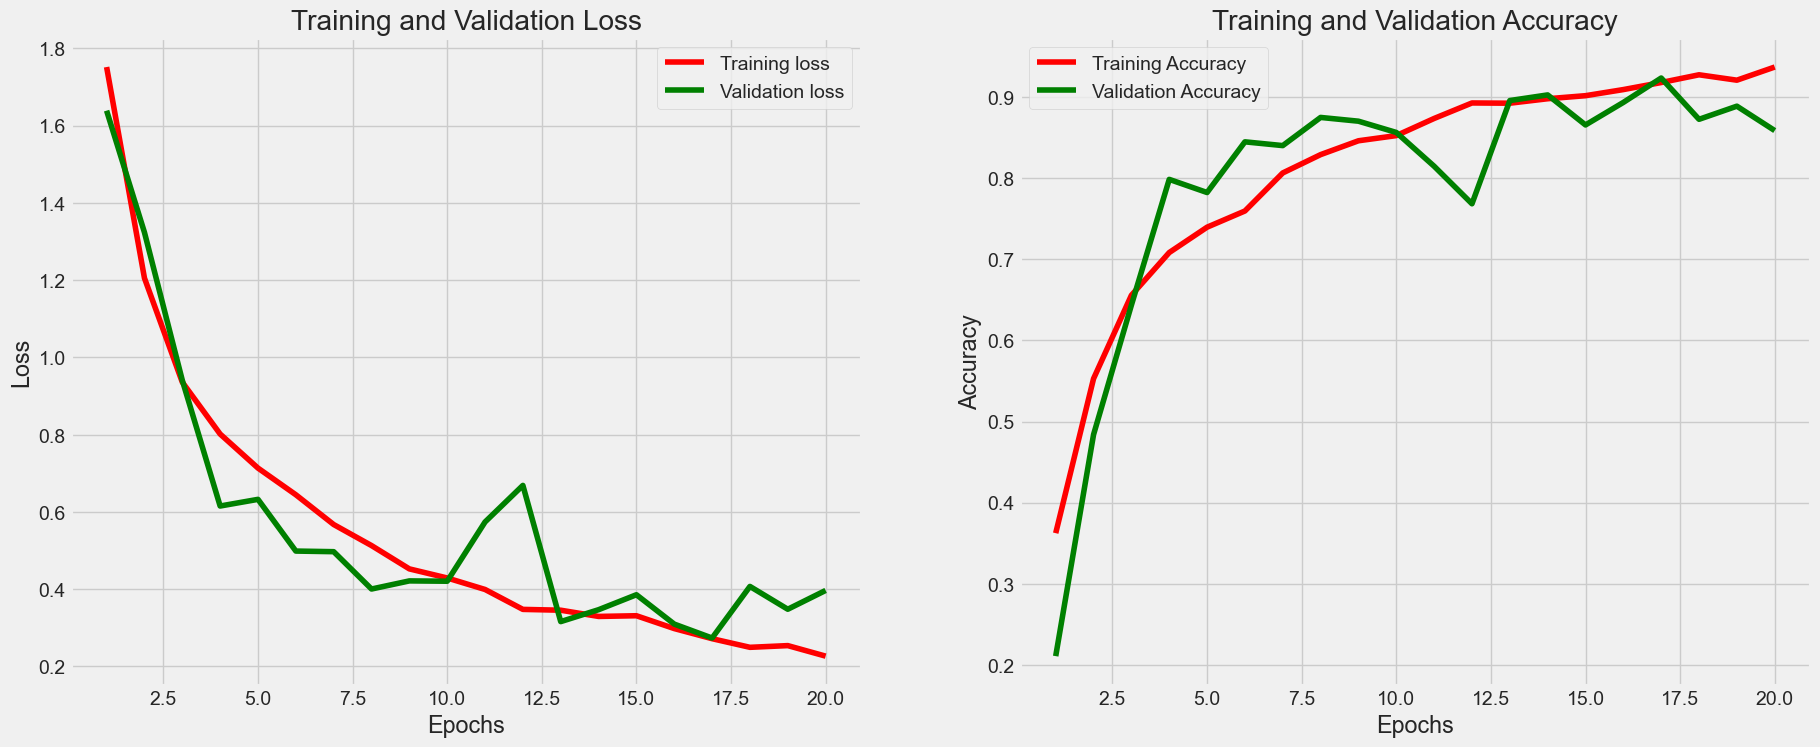

In [24]:
# Display model performance
model_performance(EfficientNetB3_history, epochs)

In [25]:
# Model evaluation with model name : EfficientNetB3_model
model_evaluation(EfficientNetB3_model)


216/216 ━━━━━━━━━━━━━━━━━━━━ 299s 1s/step - accuracy: 0.9641 - loss: 0.1608
27/27 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.8588 - loss: 0.3967
27/27 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.8958 - loss: 0.3345
Train Loss:  0.16084009408950806
Train Accuracy:  0.9640892148017883
--------------------
Validation Loss:  0.3967176377773285
Validation Accuracy:  0.8587962985038757
--------------------
Test Loss:  0.334535151720047
Test Accuracy:  0.8958333134651184


27/27 ━━━━━━━━━━━━━━━━━━━━ 27s 841ms/step


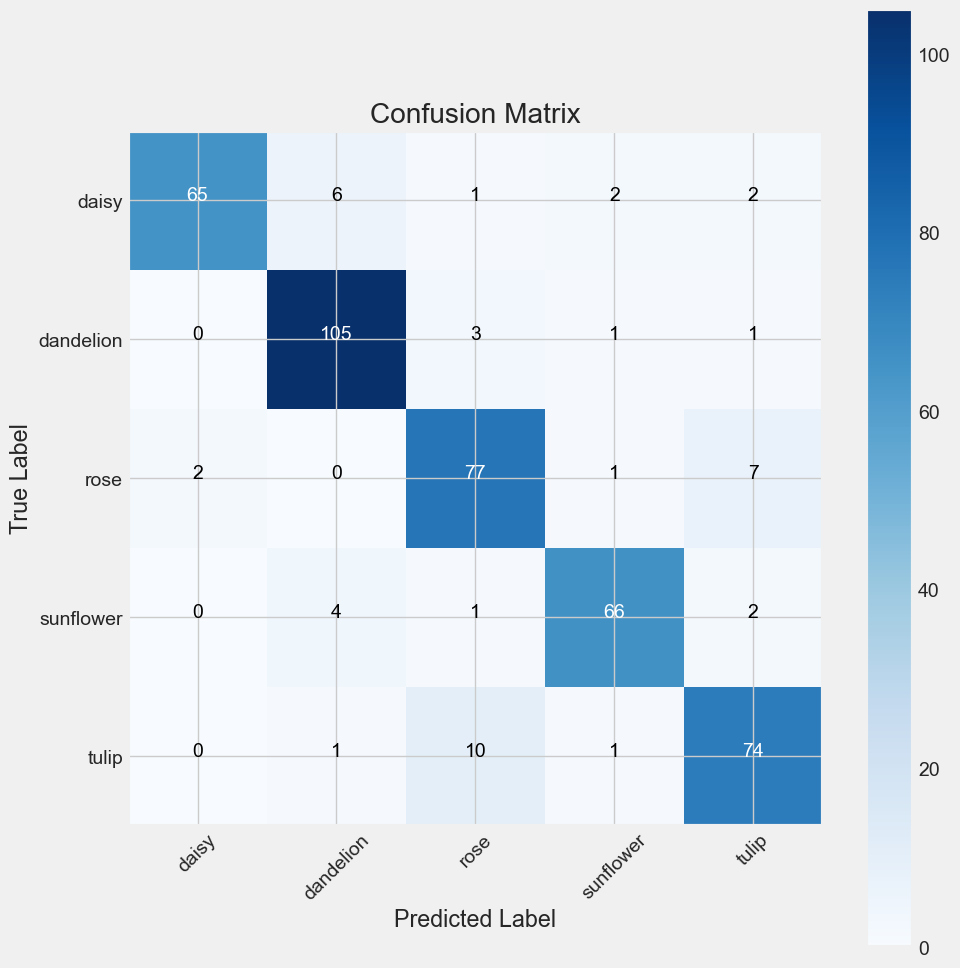

In [26]:
# get predictions
y_pred = get_pred(EfficientNetB3_model, test_gen)

# plot the confusion matrix
plot_confusion_matrix(test_gen, y_pred)

In [37]:
# Save the trained EfficientNetB3 model to disk
# Run this cell after training to persist the model
try:
    # Save in native Keras format (.keras) to avoid ValueError about missing extension
    EfficientNetB3_model.save('EfficientNetB3_model.keras')
    print('Saved model to EfficientNetB3_model.keras')
except NameError:
    print('EfficientNetB3_model not found in the current session. Run training cells first.')

Saved model to EfficientNetB3_model.keras


In [38]:
# Save class indices mapping for later prediction use
# This writes train_gen.class_indices -> class_indices.json
import json
try:
    with open('class_indices.json', 'w') as f:
        json.dump(train_gen.class_indices, f)
    print('Saved class indices to class_indices.json')
except NameError:
    print('train_gen not found in the current session. Make sure data generators are defined and run.')

Saved class indices to class_indices.json


Loading model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Prediction: sunflower (99.39%)


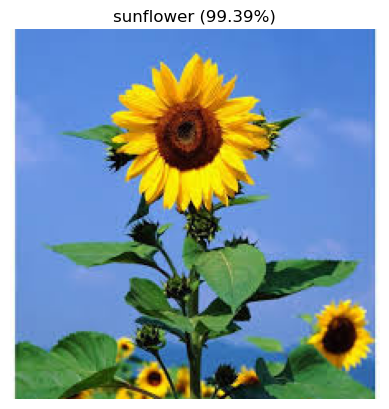

In [14]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

def predict_flower(image_path, model_path='EfficientNetB3_model.keras', class_indices_path='class_indices.json'):
    """
    Predicts the flower class for a given image path.
    """
    try:
        if not os.path.exists(model_path):
            print(f"Model file not found: {model_path}. Please train the model in the notebook first.")
            return
            
        if not os.path.exists(class_indices_path):
            print(f"Class indices file not found: {class_indices_path}. Please generate it in the notebook.")
            return

        print("Loading model...")
        model = load_model(model_path)
        
        with open(class_indices_path, 'r') as f:
            class_indices = json.load(f)
        # JSON keys are strings, values are ints. Invert: val (int) -> key (str)
        labels = {v: k for k, v in class_indices.items()}

        if not os.path.exists(image_path):
            print(f"Error: Image not found at {image_path}")
            return

        img = image.load_img(image_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array / 255.0

        predictions = model.predict(img_array)
        predicted_index = np.argmax(predictions[0])
        confidence = predictions[0][predicted_index]
        predicted_label = labels.get(predicted_index) or labels.get(str(predicted_index))

        print(f"Prediction: {predicted_label} ({confidence:.2%})")
        
        plt.imshow(img)
        plt.title(f"{predicted_label} ({confidence:.2%})")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"An error occurred: {e}")

if __name__ == "__main__":
    img_path = input("Enter the path to the flower image: ")
    # Remove quotes if user added them
    img_path = img_path.strip('"\'')
    predict_flower(img_path)
